In [1]:
# Librerias
!pip install shap xgboost lightgbm plotly ipywidgets

import pandas as pd
import numpy as np
import os

from google.colab import drive
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import shap
import matplotlib.pyplot as plt
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display


import lightgbm as lgb

import plotly.graph_objects as go

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 31.2 MB/s eta 0:00:00


In [3]:
#2 Carga de datos
drive.mount('/content/drive', force_remount=True)

path_drive = '/content/drive/MyDrive/Articulo Cientifico/Datasets/'

df_h_raw = pd.read_excel(path_drive + 'mdi_homicidiosintencionales_pm_2014_2025.xlsx',
                         sheet_name='1. Homicidios Intencionales', skiprows=11)

df_p = pd.read_excel(path_drive + 'Total_cantonal_2010-2035.xlsx')

Mounted at /content/drive


In [4]:
#3 Procesamiento
df_h = pd.DataFrame()

df_h['DPA'] = df_h_raw.iloc[:, 9].astype(str).str.split('.').str[0].str.zfill(4)
df_h['Canton'] = df_h_raw.iloc[:, 10]
df_h['Fecha'] = pd.to_datetime(df_h_raw.iloc[:, 16])

df_h['Anio'] = df_h['Fecha'].dt.year
df_h['Mes'] = df_h['Fecha'].dt.month

h_agrup = df_h.groupby(['DPA','Anio','Mes']).size().reset_index(name='Homicidios')

In [5]:
#4 Interpolación de población
df_p['DPA'] = df_p['DPA'].astype(str).str.zfill(4)

df_p_long = df_p.melt(id_vars=['DPA','canton'],
                      var_name='Anio',
                      value_name='Pob_Anual')

lista = []

for dpa in df_p['DPA'].unique():
    nombre = df_p[df_p['DPA']==dpa]['canton'].values[0]

    for anio in range(2014, 2026):
        p0 = df_p_long[(df_p_long['DPA']==dpa)&(df_p_long['Anio']==anio-1)]['Pob_Anual'].values[0]
        p1 = df_p_long[(df_p_long['DPA']==dpa)&(df_p_long['Anio']==anio)]['Pob_Anual'].values[0]

        delta = (p1 - p0)/12

        for mes in range(1,13):
            lista.append({
                'DPA': dpa,
                'Canton': nombre,
                'Anio': anio,
                'Mes': mes,
                'Poblacion': p0 + delta*mes
            })

maestro = pd.merge(pd.DataFrame(lista), h_agrup,
                   on=['DPA','Anio','Mes'], how='left').fillna(0)

maestro['Tasa'] = (maestro['Homicidios']/maestro['Poblacion'])*100000

In [6]:
import numpy as np
import pandas as pd
import os

# =========================================================
# 📌 ORDEN TEMPORAL
# =========================================================
maestro = maestro.sort_values(['DPA','Anio','Mes']).reset_index(drop=True)

# =========================================================
# 📌 VARIABLES CÍCLICAS
# =========================================================
maestro['mes_sin'] = np.sin(2*np.pi*maestro['Mes']/12)
maestro['mes_cos'] = np.cos(2*np.pi*maestro['Mes']/12)

# =========================================================
# 📌 LAGS (memoria temporal)
# =========================================================
for l in [1, 2, 3, 6, 12]:
    maestro[f'lag_{l}'] = maestro.groupby('DPA')['Tasa'].shift(l)

# =========================================================
# 📌 ROLLING FEATURES (sin leakage)
# =========================================================
maestro['media_3'] = maestro.groupby('DPA')['Tasa'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

maestro['media_6'] = maestro.groupby('DPA')['Tasa'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=1).mean()
)

maestro['max_3'] = maestro.groupby('DPA')['Tasa'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).max()
)

maestro['min_3'] = maestro.groupby('DPA')['Tasa'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).min()
)

# =========================================================
# 📌 VOLATILIDAD
# =========================================================
maestro['std_3'] = maestro.groupby('DPA')['Tasa'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=2).std()
)

maestro['std_6'] = maestro.groupby('DPA')['Tasa'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=2).std()
)

# coeficiente de variación
maestro['cv_3'] = maestro['std_3'] / (maestro['media_3'] + 1e-6)

# =========================================================
# 📌 TENDENCIA Y MOMENTUM
# =========================================================
maestro['trend'] = maestro.groupby('DPA')['Tasa'].diff()

maestro['momentum_1'] = maestro['Tasa'] / (maestro['lag_1'] + 1e-6)
maestro['momentum_3'] = maestro['Tasa'] - maestro['media_3']

# =========================================================
# 📌 SHOCK MEJORADO (SIN FALSOS POSITIVOS)
# =========================================================
z_score = (maestro['Tasa'] - maestro['media_3']) / maestro['std_3'].clip(lower=0.5)
ratio = maestro['Tasa'] / maestro['media_3'].replace(0, 1e-6)

maestro['shock'] = (
    (z_score > 2) &
    (ratio > 1.5) &
    (maestro['Tasa'] >= 3)
).astype(int)

# =========================================================
# 📌 FEATURES ESTRUCTURALES POR DPA
# =========================================================
maestro['mean_dpa'] = maestro.groupby('DPA')['Tasa'].transform('mean')
maestro['std_dpa'] = maestro.groupby('DPA')['Tasa'].transform('std')

maestro['relative_level'] = maestro['Tasa'] / (maestro['mean_dpa'] + 1e-6)

# =========================================================
# 📌 ESTACIONALIDAD ADICIONAL
# =========================================================
maestro['trimestre'] = ((maestro['Mes']-1)//3 + 1)
maestro['fin_anio'] = maestro['Mes'].isin([11,12]).astype(int)

# =========================================================
# 📌 INTERACCIONES (potencian modelos tipo árbol)
# =========================================================
maestro['lag1_x_trend'] = maestro['lag_1'] * maestro['trend']
maestro['shock_x_lag'] = maestro['shock'] * maestro['lag_1']

# =========================================================
# 📌 TRANSFORMACIONES LOG
# =========================================================
maestro['Tasa_Log'] = np.log1p(maestro['Tasa'])
maestro['Homicidios_Log'] = np.log1p(maestro['Homicidios'])

# =========================================================
# 📌 LIMPIEZA FINAL
# =========================================================
maestro = maestro.replace([np.inf, -np.inf], 0)
maestro = maestro.fillna(0)

# =========================================================
# 📌 EXPORTAR
# =========================================================
output_path = os.path.join(path_drive, 'Dataset_con_features_mejorado.xlsx')
maestro.to_excel(output_path, index=False)

print(f"✅ Dataset optimizado generado: {output_path}")

✅ Dataset optimizado generado: /content/drive/MyDrive/Articulo Cientifico/Datasets/Dataset_con_features_mejorado.xlsx


In [7]:
# =========================================================
# 📌 PREPARACIÓN
# =========================================================

df = maestro.copy()  # copiar dataset original

# usar solo datos recientes (evita cambio estructural antiguo)
df = df[df['Anio'] >= 2021].copy()

# ordenar temporalmente
df = df.sort_values(['DPA','Anio','Mes']).reset_index(drop=True)

target = 'Tasa'  # 🔥 usamos escala real

# columnas a eliminar
BASE_DROP = ['Canton','DPA','Homicidios','Homicidios_Log','Tasa_Log']

# variables independientes
X = df.drop(columns=BASE_DROP + [target], errors='ignore')

# variable objetivo
y = df[target]

In [8]:
# =========================================================
# 📌 SPLIT
# =========================================================

split = int(len(df)*0.8)  # 80% train

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# alinear columnas
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [9]:
# =========================================================
# 📌 ENTRENAMIENTO
# =========================================================

rf = RandomForestRegressor(n_estimators=400, max_depth=12, random_state=42)
rf.fit(X_train, y_train)

xgb = XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=6)
xgb.fit(X_train, y_train)

lgbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002967 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5107
[LightGBM] [Info] Number of data points in the train set: 10608, number of used features: 28
[LightGBM] [Info] Start training from score 2.482133


LGBMRegressor(learning_rate=0.03, n_estimators=500)

In [10]:
# =========================================================
# 📌 PREDICCIONES
# =========================================================

pred_rf = rf.predict(X_test)
pred_xgb = xgb.predict(X_test)
pred_lgb = lgbm.predict(X_test)

# ensemble
pred_hybrid = 0.4*pred_rf + 0.3*pred_xgb + 0.3*pred_lgb

In [11]:
# =========================================================
# 📌 MÉTRICAS
# =========================================================

def smape(y_true, y_pred):
    return np.mean(2*np.abs(y_pred-y_true)/(np.abs(y_true)+np.abs(y_pred)+1e-10))

def metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'SMAPE': smape(y_true, y_pred)*100,
        'R2': r2_score(y_true, y_pred)
    }

results = pd.DataFrame({
    'RF': metrics(y_test, pred_rf),
    'XGB': metrics(y_test, pred_xgb),
    'LGBM': metrics(y_test, pred_lgb),
    'Hybrid': metrics(y_test, pred_hybrid)
}).T

print(results)

             MAE      RMSE       SMAPE        R2
RF      0.061877  0.716266    1.895335  0.961501
XGB     0.092127  0.895927  147.309568  0.939765
LGBM    0.089206  0.989314  147.061296  0.926553
Hybrid  0.068994  0.806940  146.819673  0.951136


/tmp/ipykernel_33082/2523005624.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot = df_test_full.groupby('fecha').apply(lambda x: pd.Series({



=== MÉTRICAS ===
             MAE      RMSE     SMAPE        R2
RF      0.037319  0.048652  2.831987  0.995199
XGB     0.052287  0.067603  4.212304  0.990731
LGBM    0.045775  0.063728  3.099769  0.991763
Hybrid  0.039673  0.050020  3.065501  0.994925


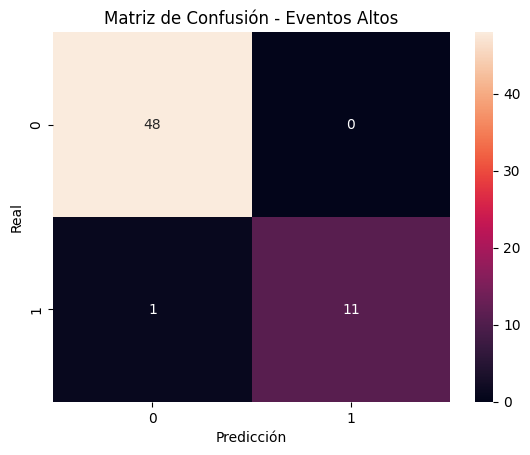


=== CLASIFICACIÓN DE PICOS ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        48
           1       1.00      0.92      0.96        12

    accuracy                           0.98        60
   macro avg       0.99      0.96      0.97        60
weighted avg       0.98      0.98      0.98        60


=== IMPORTANCIA VARIABLES ===
           feature  importance
19      momentum_3    0.387775
23  relative_level    0.271926
10         media_3    0.084450
26    lag1_x_trend    0.061680
22         std_dpa    0.053181
21        mean_dpa    0.037875
11         media_6    0.034773
12           max_3    0.024673
17           trend    0.012032
13           min_3    0.010833
5            lag_1    0.005365
8            lag_6    0.002602
2        Poblacion    0.001922
18      momentum_1    0.001875
15           std_6    0.001796


In [12]:
# =========================================================
# 📌 1. DATAFRAME COMPLETO TEST
# =========================================================

df_test_full = df.iloc[split:].copy()

# agregar predicciones
df_test_full['Real'] = y_test.values
df_test_full['RF'] = pred_rf
df_test_full['XGB'] = pred_xgb
df_test_full['LGBM'] = pred_lgb
df_test_full['Hybrid'] = pred_hybrid

# fecha
df_test_full['fecha'] = pd.to_datetime(
    df_test_full['Anio'].astype(str) + '-' +
    df_test_full['Mes'].astype(str) + '-01'
)

# =========================================================
# 📌 2. AGREGACIÓN NIVEL PAÍS (PONDERADA)
# =========================================================

def tasa_pais(df, col):
    return (df[col] * df['Poblacion']).sum() / df['Poblacion'].sum()

df_plot = df_test_full.groupby('fecha').apply(lambda x: pd.Series({
    'Real': tasa_pais(x, 'Real'),
    'RF': tasa_pais(x, 'RF'),
    'XGB': tasa_pais(x, 'XGB'),
    'LGBM': tasa_pais(x, 'LGBM'),
    'Hybrid': tasa_pais(x, 'Hybrid')
})).reset_index()

# =========================================================
# 📊 3. GRÁFICA MODELOS vs REAL
# =========================================================

fig = go.Figure()

fig.add_trace(go.Scatter(x=df_plot['fecha'], y=df_plot['Real'],
                         name='Real', line=dict(width=4)))

fig.add_trace(go.Scatter(x=df_plot['fecha'], y=df_plot['RF'], name='RF'))
fig.add_trace(go.Scatter(x=df_plot['fecha'], y=df_plot['XGB'], name='XGB'))
fig.add_trace(go.Scatter(x=df_plot['fecha'], y=df_plot['LGBM'], name='LGBM'))
fig.add_trace(go.Scatter(x=df_plot['fecha'], y=df_plot['Hybrid'], name='Hybrid'))

fig.update_layout(
    title="Modelos vs Real (Nivel País)",
    template="plotly_white"
)

fig.show()

# =========================================================
# 📊 4. MÉTRICAS
# =========================================================

def smape(y_true, y_pred):
    return np.mean(2*np.abs(y_pred-y_true)/(np.abs(y_true)+np.abs(y_pred)+1e-10))

def metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'SMAPE': smape(y_true, y_pred)*100,
        'R2': r2_score(y_true, y_pred)
    }

results = pd.DataFrame({
    'RF': metrics(df_plot['Real'], df_plot['RF']),
    'XGB': metrics(df_plot['Real'], df_plot['XGB']),
    'LGBM': metrics(df_plot['Real'], df_plot['LGBM']),
    'Hybrid': metrics(df_plot['Real'], df_plot['Hybrid'])
}).T

print("\n=== MÉTRICAS ===")
print(results)

# =========================================================
# 📉 5. RESIDUOS (MODELO HÍBRIDO)
# =========================================================

residuals = df_plot['Real'] - df_plot['Hybrid']

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_plot['fecha'],
    y=residuals,
    mode='lines',
    name='Error'
))

fig.add_hline(y=0)

fig.update_layout(title="Errores en el tiempo (Hybrid)")

fig.show()

# =========================================================
# 📦 6. DISTRIBUCIÓN DE ERRORES
# =========================================================

import plotly.express as px

fig = px.histogram(residuals, nbins=30, title="Distribución de errores")
fig.show()

# =========================================================
# 📈 7. REAL vs PREDICHO
# =========================================================

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_plot['Real'],
    y=df_plot['Hybrid'],
    mode='markers',
    name='Predicción'
))

fig.add_trace(go.Scatter(
    x=[df_plot['Real'].min(), df_plot['Real'].max()],
    y=[df_plot['Real'].min(), df_plot['Real'].max()],
    mode='lines',
    name='Perfecto'
))

fig.update_layout(title="Real vs Predicho (Hybrid)")

fig.show()

# =========================================================
# 🔥 8. MATRIZ DE CONFUSIÓN (PICOS)
# =========================================================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

threshold = df_plot['Real'].quantile(0.80)

y_true_cls = (df_plot['Real'] >= threshold).astype(int)
y_pred_cls = (df_plot['Hybrid'] >= threshold).astype(int)

cm = confusion_matrix(y_true_cls, y_pred_cls)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de Confusión - Eventos Altos")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

print("\n=== CLASIFICACIÓN DE PICOS ===")
print(classification_report(y_true_cls, y_pred_cls))

# =========================================================
# 📊 9. IMPORTANCIA DE VARIABLES
# =========================================================

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\n=== IMPORTANCIA VARIABLES ===")
print(importance.head(15))

In [13]:
# =========================================================
# 📌 FORECAST ESTABLE
# =========================================================

df_forecast = df.copy()

# congelar valores reales
media_real = df.groupby('DPA')['media_3'].last()
std_real = df.groupby('DPA')['std_3'].last()

forecast = []

for i in range(12):

    last = df_forecast.groupby('DPA').tail(1).copy()
    new = last.copy()

    # avanzar mes
    mask = new['Mes'] == 12
    new.loc[mask,'Mes'] = 1
    new.loc[mask,'Anio'] += 1
    new.loc[~mask,'Mes'] += 1

    # estacionalidad
    new['mes_sin'] = np.sin(2*np.pi*new['Mes']/12)
    new['mes_cos'] = np.cos(2*np.pi*new['Mes']/12)

    # congelar features
    new['media_3'] = new['DPA'].map(media_real)
    new['std_3'] = new['DPA'].map(std_real)

    # input modelo
    X_future = new.drop(columns=BASE_DROP + ['Tasa'], errors='ignore')
    X_future = X_future.reindex(columns=X_train.columns, fill_value=0)

    # predicción ensemble
    pred = 0.4*rf.predict(X_future) + 0.3*xgb.predict(X_future) + 0.3*lgbm.predict(X_future)

    # inercia 🔥
    lag1 = new['Tasa'].values
    pred = 0.6*lag1 + 0.4*pred

    # control de caída
    pred = np.maximum(pred, lag1*0.85)

    new['Tasa'] = pred

    df_forecast = pd.concat([df_forecast, new], ignore_index=True)
    forecast.append(new)

df_2026 = pd.concat(forecast)

In [14]:
# =========================================================
# 📊 TASA PAÍS
# =========================================================

df_2026['fecha'] = pd.to_datetime(df_2026['Anio'].astype(str)+'-'+df_2026['Mes'].astype(str)+'-01')

df_pais_2026 = df_2026.groupby('fecha').apply(
    lambda x: (x['Tasa']*x['Poblacion']).sum()/x['Poblacion'].sum()
).reset_index(name='Tasa')

df_hist = maestro.copy()
df_hist['fecha'] = pd.to_datetime(df_hist['Anio'].astype(str)+'-'+df_hist['Mes'].astype(str)+'-01')

df_pais_hist = df_hist.groupby('fecha').apply(
    lambda x: (x['Tasa']*x['Poblacion']).sum()/x['Poblacion'].sum()
).reset_index(name='Tasa')

/tmp/ipykernel_33082/3407601834.py:7: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_33082/3407601834.py:14: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [15]:
# =========================================================
# 📈 FORECAST FINAL
# =========================================================

fig = go.Figure()

fig.add_trace(go.Scatter(x=df_pais_hist['fecha'], y=df_pais_hist['Tasa'], name='Histórico'))
fig.add_trace(go.Scatter(x=df_pais_2026['fecha'], y=df_pais_2026['Tasa'], name='Forecast'))

fig.add_vline(x=df_pais_2026['fecha'].min(), line_dash="dash")

fig.update_layout(title="Forecast País 2026", template="plotly_white")

fig.show()

In [21]:
print(cm)

print(classification_report(y_true_cls, y_pred_cls))

[[48  0]
 [ 1 11]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        48
           1       1.00      0.92      0.96        12

    accuracy                           0.98        60
   macro avg       0.99      0.96      0.97        60
weighted avg       0.98      0.98      0.98        60

